In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss

# 2. EDA

In [3]:
#read polymarket data
import sys
import os
import polars as pl
#from pathlib import path

sys.path.append(os.path.abspath('..'))
# Import the loader from the template provided by the project
from eda_starter_template import load_polymarket_data, POLYMARKET_DIR

# Load the dictionary of DataFrames
poly_data_dict = load_polymarket_data(POLYMARKET_DIR)

# Extract individual DataFrames for easier use
if poly_data_dict:
    df_markets = poly_data_dict.get("markets")
    df_odds = poly_data_dict.get("odds")
    df_summary = poly_data_dict.get("summary")
    
    print("Data loaded successfully!")
else:
    print("Data directory not found. Check if the 'data/Polymarket' folder exists.")

Loading Polymarket data from D:\7406Poly\polymarket-analysis-team66 - omsa\data\Polymarket...
[Memory] Before loading Polymarket data: 229.77 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 430.32 MB (Δ 200.55 MB)
Data loaded successfully!


In [4]:
df_markets.head()

market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""242851""","""Will Bongbong Marcos be electe…","""will-bongbong-marcos-be-electe…","""will-bongbong-marcos-be-electe…","""Global Politics""",21533.53,true,true,2022-04-05 20:37:30,2022-05-09 00:00:00
"""242873""","""Will Sarah Palin win Alaska's …","""will-sarah-palin-win-in-the-al…","""will-sarah-palin-win-in-the-al…","""US-current-affairs""",79783.23,true,true,2022-04-05 22:41:57,2022-08-16 00:00:00
"""242918""","""Will US student loan payments …","""will-us-student-loan-payments-…","""will-us-student-loan-payments-…","""US-current-affairs""",18946.72,true,true,2022-04-05 23:33:47,2022-11-08 00:00:00
"""243183""","""Will $ETH be above $3,000 on A…","""will-eth-be-above-3000-on-apri…","""will-eth-be-above-3000-on-apri…","""Crypto""",974114.26,true,true,2022-04-12 16:51:10,2022-04-20 00:00:00
"""243192""","""Will Brian Kemp win the Republ…","""will-brian-kemp-win-the-republ…","""who-will-win-the-republican-no…","""US-current-affairs""",7024.92,true,true,2022-04-13 01:40:25,2022-05-24 00:00:00


In [5]:
tokens_path = POLYMARKET_DIR / "finance_politics_tokens.parquet"
event_path = POLYMARKET_DIR / "finance_politics_event_stats.parquet"
trades_path = POLYMARKET_DIR / "finance_politics_trades.parquet"

df_tokens = (
    pl.scan_parquet(tokens_path)
    .collect()
)
df_event = (
    pl.scan_parquet(event_path)
    .collect()
)

if trades_path.exists():
    trades_df = pl.scan_parquet(trades_path).collect()
    
    # Fix timestamp corruption
    for col in trades_df.columns:
        if any(x in col.lower() for x in ["timestamp", "trade", "created_at", "end_date"]):
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                if not trades_df[col].is_empty() and trades_df[col].max() < datetime(2020, 1, 1):
                    trades_df = trades_df.with_columns((pl.col(col).cast(pl.Int64) * 1000).cast(pl.Datetime))
                    
            # Enforce 2020+ constraint (replace placeholders/zeros with null)
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                    trades_df = trades_df.with_columns(
                        pl.when(pl.col(col) < datetime(2020, 1, 1))
                        .then(None)
                        .otherwise(pl.col(col))
                        .alias(col)
                    )
                
    print(f"Loaded {len(trades_df)} trades records.")

Loaded 27013724 trades records.


In [6]:
trades_df.head()

trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address
str,str,str,datetime[μs],f64,f64,str,str,str
"""0x036e539d9361b15d9ebee9bbd1ae…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:05,0.977,281.054246,"""BUY""","""0x27d76669db4321111b08fcc7e1a5…","""0xc5d563a36ae78145c45a50134d48…"
"""0x8685bb4a3134f9f664ed7e619b8e…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:17,0.977,28.0,"""BUY""","""0x33dcee9b336230ed7460c98bec8f…","""0xc5d563a36ae78145c45a50134d48…"
"""0xab71cfe8f3cb18e629b873b65b84…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:31,0.977,182.0,"""BUY""","""0x87370aa54b8f70fa1c9637f367aa…","""0xc5d563a36ae78145c45a50134d48…"
"""0xfe619b29a0b6aa958cbd565c18f0…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:49,0.977081,49.0,"""BUY""","""0xa3ad70cf48a2f2b44163e798223c…","""0xc5d563a36ae78145c45a50134d48…"
"""0x953032bcaecd5bf0007c44acddb0…","""570360""","""214897725164100385865567443423…",2025-11-19 13:45:25,0.978,147.8,"""BUY""","""0x4ee06f42e20ee128db78d4225217…","""0xc5d563a36ae78145c45a50134d48…"


In [7]:
df_tokens.head()

market_id,token_id,outcome
str,str,str
"""240383""","""555875344331027638590324435858…","""Yes"""
"""240383""","""111837615529992437689409005124…","""No"""
"""240384""","""113459643164060403919504712048…","""Yes"""
"""240384""","""110606609354376812966157988257…","""No"""
"""240385""","""505435736314143687770680977181…","""Yes"""


In [8]:
def prepare_calibration_data_optimized(trades_df, df_tokens, df_markets):
    # Convert to LazyFrames if they aren't already
    # This allows Polars to optimize the execution plan
    trades_lazy = trades_df.lazy()
    tokens_lazy = df_tokens.lazy()
    markets_lazy = df_markets.lazy()

    # 1. Select ONLY necessary columns and filter outcomes first
    # This reduces the data volume before the join
    yes_tokens = (
        tokens_lazy
        .filter(pl.col("outcome") == "Yes")
        .select(["token_id", "market_id"])
    )

    # 2. Perform the join lazily
    # Join trades with filtered tokens first
    df_joined = (
        trades_lazy
        .select(["token_id", "market_id", "timestamp", "price", "size"]) # Projection
        .join(yes_tokens, on=["token_id", "market_id"], how="inner")
    )

    # 3. Join with market metadata
    df_with_meta = df_joined.join(
        markets_lazy.select(["market_id", "category", "volume", "closed", "end_date"]),
        on="market_id",
        how="left"
    )

    # 4. Outcome Resolution Logic 
    # Finding the final price to determine ground truth
    outcomes = (
        df_with_meta
        .filter(pl.col("closed") == True)
        .sort("timestamp")
        .group_by("market_id")
        .agg(pl.col("price").last().alias("final_price"))
        .with_columns(
            #threshold to account for last-trade slippage and floating-point precision
            pl.when(pl.col("final_price") > 0.9)
            .then(pl.lit(1))
            .otherwise(pl.lit(0))
            .alias("result")
        )
    )

    # 5. Final Join and Execution
    # We use collect(streaming=True) to handle datasets larger than RAM
    final_df = (
        df_with_meta
        .join(outcomes.select(["market_id", "result"]), on="market_id", how="left")
        .collect(streaming=True)
    )
    
    return final_df

# Usage
#df_analysis = prepare_calibration_data_optimized(trades_df, df_tokens, df_markets)

In [9]:
df_analysis = prepare_calibration_data_optimized(trades_df, df_tokens, df_markets)

C:\Users\quant\AppData\Local\Temp\ipykernel_33076\3844771595.py:53: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True)


In [10]:
df_analysis.head()

token_id,market_id,timestamp,price,size,category,volume,closed,end_date,result
str,str,datetime[μs],f64,f64,str,f64,bool,datetime[μs],i32
"""964450893577581595797327255275…","""607633""",2025-09-22 18:28:36,0.999,34.0,"""""",72.0,true,2025-09-22 20:00:00,1
"""964450893577581595797327255275…","""607633""",2025-09-22 19:44:14,0.999,38.0,"""""",72.0,true,2025-09-22 20:00:00,1
"""515985971106518663119683411456…","""577008""",2025-08-17 02:23:58,0.31,78.0,"""""",48485.852136,true,2025-08-18 00:00:00,0
"""515985971106518663119683411456…","""577008""",2025-08-17 05:17:15,0.26,150.0,"""""",48485.852136,true,2025-08-18 00:00:00,0
"""515985971106518663119683411456…","""577008""",2025-08-17 05:17:15,0.26,13.9,"""""",48485.852136,true,2025-08-18 00:00:00,0


In [11]:
#check trades the linked to market with no outcome
print(f"Total trades: {len(df_analysis)}")
print(f"Trades with outcomes: {df_analysis['result'].count()}")
print(f"Trades without outcomes (NaNs): {df_analysis['result'].null_count()}")

Total trades: 4734825
Trades with outcomes: 3962816
Trades without outcomes (NaNs): 772009


In [12]:
from sklearn.model_selection import GroupShuffleSplit

# Prepare arrays for sklearn
df_analysis = df_analysis.drop_nulls(subset=["result"])
X = df_analysis["price"].to_numpy().reshape(-1, 1)
y = df_analysis["result"].to_numpy()
groups = df_analysis["market_id"].to_numpy()

# Split Data: 80% Training, 20% Testing
# Use GroupShuffleSplit to keep markets whole
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# TRAINING 

# Platt Scaling (Logistic Regression)
platt_model = LogisticRegression()
platt_model.fit(X_train, y_train)

# Isotonic Regression 
# Note: Isotonic expects 1D input for X
iso_model = IsotonicRegression(out_of_bounds='clip')
iso_model.fit(X_train.flatten(), y_train)

# EVALUATION  

# Raw Market (No correction, just use the original test prices)
p_raw_test = X_test.flatten()

# Platt Predictions on Test Set
p_platt_test = platt_model.predict_proba(X_test)[:, 1]

# Isotonic Predictions on Test Set
p_iso_test = iso_model.transform(X_test.flatten())

# --- METRIC CALCULATION (Using Test Set Only) ---

def calculate_ece(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    return np.mean(np.abs(prob_true - prob_pred))

# Brier Scores
bs_raw = brier_score_loss(y_test, p_raw_test)
bs_platt = brier_score_loss(y_test, p_platt_test)
bs_iso = brier_score_loss(y_test, p_iso_test)

# ECE
ece_raw = calculate_ece(y_test, p_raw_test)
ece_platt = calculate_ece(y_test, p_platt_test)
ece_iso = calculate_ece(y_test, p_iso_test)

print(f"--- TEST SET RESULTS ---")
print(f"Brier Scores - Raw: {bs_raw:.4f}, Platt: {bs_platt:.4f}, Isotonic: {bs_iso:.4f}")
print(f"ECE - Raw: {ece_raw:.4f}, Platt: {ece_platt:.4f}, Isotonic: {ece_iso:.4f}")

--- TEST SET RESULTS ---
Brier Scores - Raw: 0.0925, Platt: 0.1017, Isotonic: 0.0947
ECE - Raw: 0.1075, Platt: 0.1819, Isotonic: 0.1322


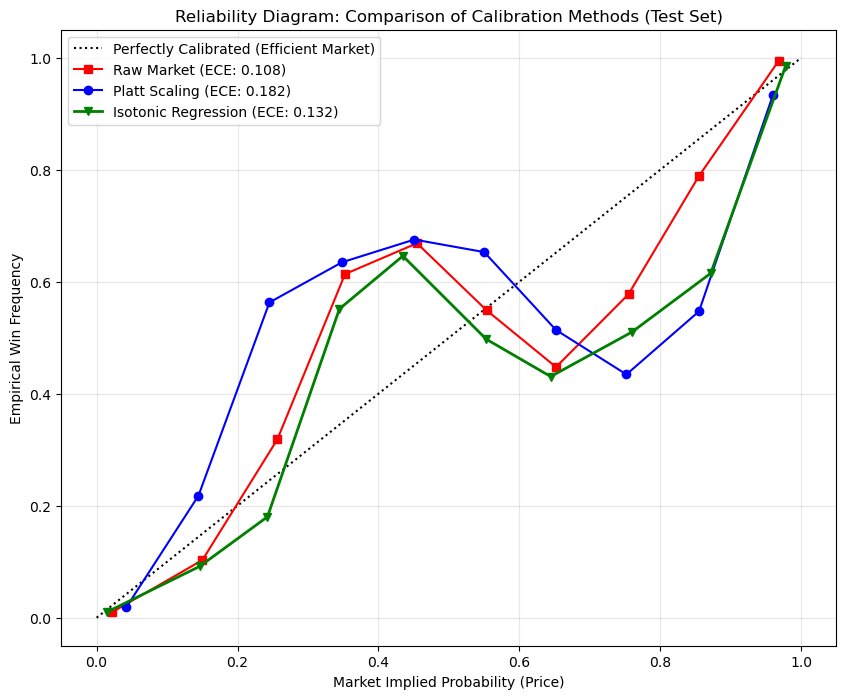

In [13]:
# Curves
prob_true_raw, prob_pred_raw = calibration_curve(y_test, p_raw_test, n_bins=10)
prob_true_platt, prob_pred_platt = calibration_curve(y_test, p_platt_test, n_bins=10)
prob_true_iso, prob_pred_iso = calibration_curve(y_test, p_iso_test, n_bins=10)

# Plotting
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated (Efficient Market)")

# Plot Raw Market
plt.plot(prob_pred_raw, prob_true_raw, "s-", label=f"Raw Market (ECE: {ece_raw:.3f})", color='red')

# Plot Platt Scaling
plt.plot(prob_pred_platt, prob_true_platt, "o-", label=f"Platt Scaling (ECE: {ece_platt:.3f})", color='blue')

# Plot Isotonic Regression
plt.plot(prob_pred_iso, prob_true_iso, "v-", label=f"Isotonic Regression (ECE: {ece_iso:.3f})", color='green', linewidth=2)

plt.xlabel("Market Implied Probability (Price)")
plt.ylabel("Empirical Win Frequency")
plt.title("Reliability Diagram: Comparison of Calibration Methods (Test Set)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.savefig('../output/calibration_comparison_final.png')

In [14]:
# 1. Safe Feature Engineering
df_features = df_analysis.with_columns([
    # Time-to-Resolution (TTR)
    ((pl.col("end_date") - pl.col("timestamp")).dt.total_seconds() / 3600).alias("ttr_hours"),
    
    # SAFE Relative trade size: If volume is 0, set rel_size to 0 instead of inf
    pl.when(pl.col("volume") > 0)
      .then(pl.col("size") / pl.col("volume"))
      .otherwise(0)
      .alias("rel_size"),
    
    # SAFE Log Volume: use log1p(x) which is log(1 + x) to avoid log(0) = -inf
    (pl.col("volume").log1p()).alias("log_volume")
])

# One-Hot Encode Categories (Politics, Crypto, etc.)
df_features = df_features.to_dummies(columns=["category"])

#  Handle Volatility (Using df_odds if available, or rolling price std)
# Here we calculate volatility per market
vol_df = df_features.group_by("market_id").agg(
    pl.col("price").std().alias("market_volatility")
).fill_null(0)


# Final Safety Check: Catch any stray inf/nan that might have survived
# This replaces any infinite value with 0
df_model = df_features.with_columns([
    pl.col("rel_size").replace([float('inf'), float('-inf')], 0),
    pl.col("log_volume").replace([float('inf'), float('-inf')], 0)
]).fill_null(0) # Also fill any NaNs with 0

df_model = df_features.join(vol_df, on="market_id", how="left")

In [ ]:
import xgboost as xgb
# Select  features
feature_cols = ["price", "ttr_hours", "rel_size", "log_volume", "market_volatility"] 
feature_cols += [c for c in df_model.columns if c.startswith("category_")]

# Prepare X, y, and groups
X = df_model.select(feature_cols).to_numpy()
y = df_model["result"].to_numpy()
groups = df_model["market_id"].to_numpy()

# Grouped Split (80/20)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Train XGBoost
# We use binary:logistic to output probabilities
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective="binary:logistic",
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Get Probabilities
p_xgb_test = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
# Metrics for Test Set
bs_iso = brier_score_loss(y_test, iso_model.transform(X_test[:, 0])) # Price only
bs_xgb = brier_score_loss(y_test, p_xgb_test) # Price + Context

ece_iso = calculate_ece(y_test, iso_model.transform(X_test[:, 0]))
ece_xgb = calculate_ece(y_test, p_xgb_test)

print(f"--- Final Comparison (Test Set) ---")
print(f"Isotonic Baseline -> Brier: {bs_iso:.5f}, ECE: {ece_iso:.5f}")
print(f"XGBoost Advanced  -> Brier: {bs_xgb:.5f}, ECE: {ece_xgb:.5f}")

--- Final Comparison (Test Set) ---
Isotonic Baseline -> Brier: 0.09472, ECE: 0.13219
XGBoost Advanced  -> Brier: 0.14810, ECE: 0.16491
